# Lab 1 Solutions: NumPy for Cat vs Dog Faces

These are worked solutions for the NumPy lab. The code below fills in each scaffolded task from the student notebook.

Set `STUDENT_ID` in the first code cell. Each notebook uses it as the random seed for sampling, split suggestions, and visualization so every student gets a reproducible variant.


In [23]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from lab_utils.visualization import (
    plot_centroid_heatmap,
    plot_feature_vector,
    plot_prediction_gallery,
    show_image_gallery,
)

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data" / "cats_dogs_faces_small").exists():
            return candidate
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "cats_dogs_faces_small"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

LABELS = ("cat", "dog")
SPLITS = ("train", "val", "test")
STUDENT_ID = 10422021  # Replace with your own student ID.
SEED = int(STUDENT_ID)
np.random.seed(SEED)
NUMPY_PRED_PATH = ARTIFACT_DIR / f"lab1_numpy_predictions_{STUDENT_ID}.csv"

FEATURE_NAMES = [
    "mean_r",
    "mean_g",
    "mean_b",
    "std_r",
    "std_g",
    "std_b",
    "gray_contrast",
    "center_brightness",
    "hist_0",
    "hist_1",
    "hist_2",
    "hist_3",
    "hist_4",
    "hist_5",
    "hist_6",
    "hist_7",
]

def list_image_paths(split: str) -> list[Path]:
    paths = []
    for label in LABELS:
        label_dir = DATA_ROOT / split / label
        paths.extend(sorted(label_dir.glob("*.jpg")))
        paths.extend(sorted(label_dir.glob("*.png")))
    return sorted(paths)

def load_image(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image.convert("RGB"))

def label_from_path(path: Path) -> str:
    return path.parent.name

def sample_per_class(paths: list[Path], n_per_class: int, seed_offset: int = 0) -> list[Path]:
    selected = []
    for label_index, label in enumerate(LABELS):
        label_paths = [path for path in paths if label_from_path(path) == label]
        if not label_paths:
            continue
        rng = np.random.default_rng(SEED + seed_offset + label_index)
        chosen_indices = rng.permutation(len(label_paths))[: min(n_per_class, len(label_paths))]
        selected.extend([label_paths[idx] for idx in chosen_indices])
    return selected

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the prepared subset at data/cats_dogs_faces_small/."
    )

train_paths = list_image_paths("train")
test_paths = list_image_paths("test")

print(f"Student ID seed: {STUDENT_ID}")
print(f"Train images: {len(train_paths)}")
print(f"Test images:  {len(test_paths)}")
print(f"Example file: {train_paths[0] if train_paths else 'No files found'}")


Student ID seed: 10422021
Train images: 420
Test images:  90
Example file: /Users/fuisloy/lab/data/cats_dogs_faces_small/train/cat/cat_0000.jpg


### Visual Helper: Preview the Dataset

Before we start writing NumPy logic, use the shared utility below to look at a few training examples from each class.


(<Figure size 900x600 with 6 Axes>,
 array([[<Axes: title={'center': 'cat: cat_0191.jpg'}>,
         <Axes: title={'center': 'cat: cat_0165.jpg'}>,
         <Axes: title={'center': 'cat: cat_0026.jpg'}>],
        [<Axes: title={'center': 'dog: dog_0026.jpg'}>,
         <Axes: title={'center': 'dog: dog_0082.jpg'}>,
         <Axes: title={'center': 'dog: dog_0021.jpg'}>]], dtype=object))

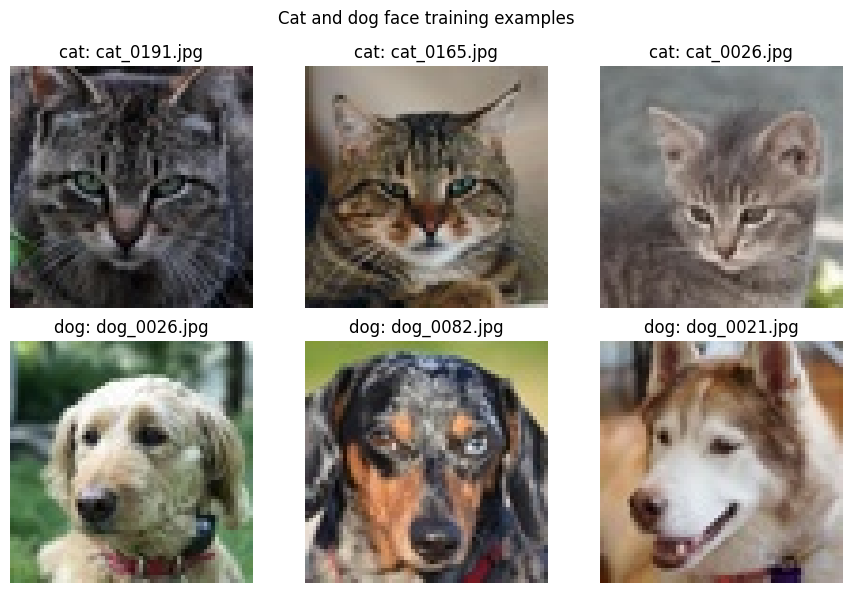

In [24]:
preview_paths = sample_per_class(train_paths, n_per_class=3, seed_offset=10)
preview_images = [load_image(path) for path in preview_paths]
preview_titles = [f"{label_from_path(path)}: {path.name}" for path in preview_paths]
show_image_gallery(
    preview_images,
    titles=preview_titles,
    ncols=3,
    figsize=(9, 6),
    suptitle="Cat and dog face training examples",
)


## Question 1: What does one image look like as an array?

Complete the function below so it returns the key properties of a color image:

- height
- width
- number of channels
- dtype
- minimum pixel value
- maximum pixel value

Then display one sample image.


shape: (64, 64, 3)
dtype: uint8
range: 6 to 255


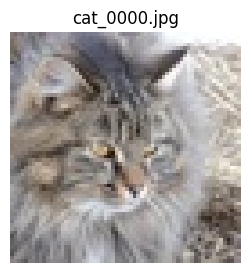

In [25]:
sample_path = train_paths[0]
sample_image = load_image(sample_path)

def describe_image(image: np.ndarray) -> tuple[int, int, int, str, int, int]:
    height, width, channels = image.shape
    dtype_name = str(image.dtype)
    pixel_min = int(image.min())
    pixel_max = int(image.max())
    return height, width, channels, dtype_name, pixel_min, pixel_max

height, width, channels, dtype_name, pixel_min, pixel_max = describe_image(sample_image)

print("shape:", sample_image.shape)
print("dtype:", dtype_name)
print("range:", pixel_min, "to", pixel_max)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(sample_path.name)
plt.axis("off")

assert channels == 3, "A color image should have 3 channels."
assert 0 <= pixel_min <= pixel_max <= 255, "Pixel values should stay in the 0-255 range."


## Question 2: Why do we normalize pixels?

Complete these two helper functions:

- `to_float01`: convert an unsigned integer image into floating point values in `[0, 1]`
- `rgb_to_gray`: turn an RGB image into a single grayscale channel using weighted averaging

Use the standard weights `0.299`, `0.587`, and `0.114`.


float dtype: float32
float range: 0.023529412 to 1.0
gray shape: (64, 64)


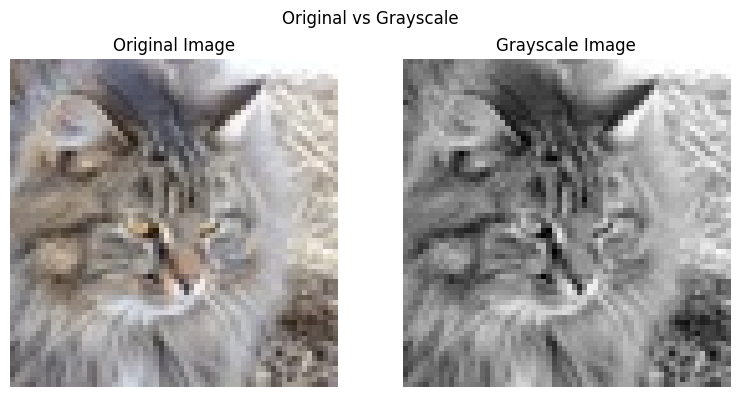

In [26]:
def to_float01(image: np.ndarray) -> np.ndarray:
    return image.astype(np.float32) / 255.0

def rgb_to_gray(image_float: np.ndarray) -> np.ndarray:
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    return np.tensordot(image_float, weights, axes=([-1], [0]))

sample_float = to_float01(sample_image)
sample_gray = rgb_to_gray(sample_float)

print("float dtype:", sample_float.dtype)
print("float range:", sample_float.min(), "to", sample_float.max())
print("gray shape:", sample_gray.shape)

assert sample_float.dtype == np.float32, "The normalized image should use float32."
assert sample_float.min() >= 0.0 and sample_float.max() <= 1.0, "Normalization should produce values in [0, 1]."
assert sample_gray.shape == sample_image.shape[:2], "A grayscale image should keep only height and width."

# Visualize the original and grayscale images side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_image)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(sample_gray, cmap="gray")
axes[1].set_title("Grayscale Image")
axes[1].axis("off")
plt.suptitle("Original vs Grayscale")
plt.tight_layout()
plt.show()

## Question 3: Can you crop and flip with slicing?

Complete the functions below:

- `center_crop`: return a centered square crop
- `flip_horizontal`: mirror the image from left to right using slicing only

Try a crop size of `48` on a `64 x 64` image.


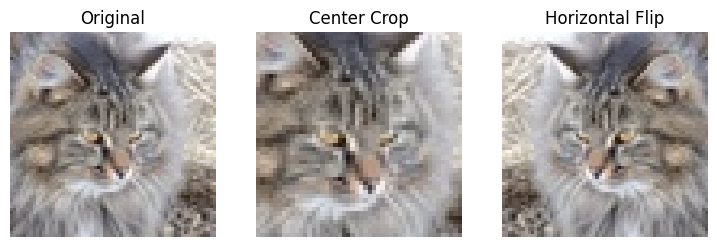

In [27]:
def center_crop(image: np.ndarray, crop_size: int = 48) -> np.ndarray:
    height, width = image.shape[:2]
    crop_size = min(crop_size, height, width)
    start_y = (height - crop_size) // 2
    start_x = (width - crop_size) // 2
    return image[start_y:start_y + crop_size, start_x:start_x + crop_size]

def flip_horizontal(image: np.ndarray) -> np.ndarray:
    return image[:, ::-1]

cropped_image = center_crop(sample_image, crop_size=48)
flipped_image = flip_horizontal(sample_image)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(sample_image)
axes[0].set_title("Original")
axes[1].imshow(cropped_image)
axes[1].set_title("Center Crop")
axes[2].imshow(flipped_image)
axes[2].set_title("Horizontal Flip")

for ax in axes:
    ax.axis("off")

assert cropped_image.shape[0] == 48 and cropped_image.shape[1] == 48, "The crop should be 48 x 48."
assert flipped_image.shape == sample_image.shape, "Flipping should not change the image shape."


## Question 4: How can we turn one image into a feature vector?

Build a small hand-crafted feature vector with:

- mean RGB values
- standard deviation of RGB values
- grayscale contrast (standard deviation)
- mean brightness of the center crop
- an 8-bin grayscale histogram

The final feature vector should have **16 values**.


Feature vector length: 16
[0.60073406 0.57973462 0.56966335 0.16299395 0.1677117  0.17073019
 0.16608086 0.57375324 0.0012207  0.01660156 0.10131836 0.18432617
 0.28173828 0.25927734 0.11645508 0.0390625 ]


(<Figure size 1200x350 with 1 Axes>,
 <Axes: title={'center': 'Hand-crafted feature vector for one image'}, ylabel='Value'>)

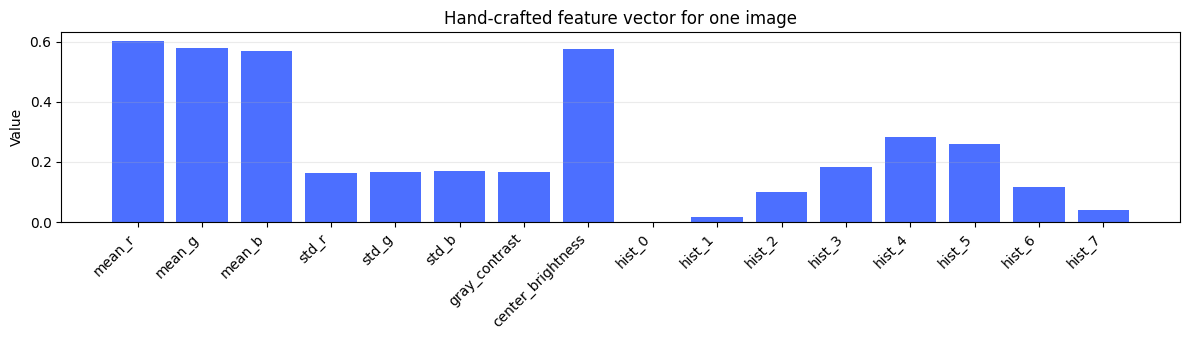

In [28]:
def extract_features(image: np.ndarray) -> np.ndarray:
    image_float = to_float01(image)
    gray = rgb_to_gray(image_float)
    mean_rgb = image_float.mean(axis=(0, 1))
    std_rgb = image_float.std(axis=(0, 1))
    gray_contrast = np.array([gray.std()], dtype=np.float32)

    center = center_crop(image_float, crop_size=min(48, image_float.shape[0], image_float.shape[1]))
    center_gray = rgb_to_gray(center)
    center_brightness = np.array([center_gray.mean()], dtype=np.float32)

    hist_counts, _ = np.histogram(gray, bins=8, range=(0.0, 1.0))
    hist = hist_counts.astype(np.float32) / hist_counts.sum()

    return np.concatenate([
        mean_rgb.astype(np.float32),
        std_rgb.astype(np.float32),
        gray_contrast,
        center_brightness,
        hist,
    ])

feature_example = extract_features(sample_image)
print("Feature vector length:", feature_example.shape[0])
print(feature_example)

assert feature_example.ndim == 1, "Features should be a 1D vector."
assert feature_example.shape[0] == 16, "Your handcrafted feature vector should contain 16 values."

plot_feature_vector(
    feature_example,
    FEATURE_NAMES,
    title="Hand-crafted feature vector for one image",
)


## Question 5: Train a nearest-centroid baseline

Use the feature vectors to build a simple classifier:

1. Take a small balanced subset of the training images
2. Compute one centroid for cats and one centroid for dogs
3. Predict the label of a test image using the closest centroid

This is not a deep model. It is just a fast NumPy baseline that gives us something to compare against later.


Train feature matrix: (160, 16)
Test feature matrix: (60, 16)
Centroids: (2, 16)


(<Figure size 1200x280 with 2 Axes>,
 <Axes: title={'center': 'Nearest-centroid feature profiles'}>)

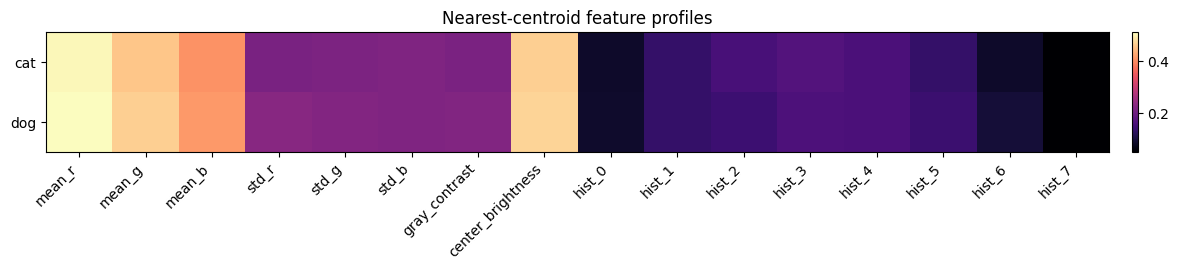

In [29]:
def build_feature_matrix(paths: list[Path]) -> tuple[np.ndarray, np.ndarray]:
    X = np.stack([extract_features(load_image(path)) for path in paths]).astype(np.float32)
    y = np.array([0 if label_from_path(path) == "cat" else 1 for path in paths], dtype=np.int64)
    return X, y

def compute_centroids(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.stack([X[y == class_id].mean(axis=0) for class_id in range(2)]).astype(np.float32)

def predict_with_centroids(X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    return distances.argmin(axis=1)

train_subset = sample_per_class(train_paths, n_per_class=80, seed_offset=20)
test_subset = sample_per_class(test_paths, n_per_class=30, seed_offset=30)

X_train, y_train = build_feature_matrix(train_subset)
X_test, y_test = build_feature_matrix(test_subset)

centroids = compute_centroids(X_train, y_train)
test_pred = predict_with_centroids(X_test, centroids)

print("Train feature matrix:", X_train.shape)
print("Test feature matrix:", X_test.shape)
print("Centroids:", centroids.shape)

assert X_train.shape[1] == 16, "Each training example should have 16 features."
assert centroids.shape == (2, 16), "There should be one centroid per class."
assert test_pred.shape == y_test.shape, "Predictions should match the number of test labels."

plot_centroid_heatmap(
    centroids,
    FEATURE_NAMES,
    class_names=LABELS,
    title="Nearest-centroid feature profiles",
)


## Question 6: Evaluate and save the baseline predictions

Compute test accuracy, inspect a few mistakes, and save your predictions to:

`artifacts/lab1_numpy_predictions_<student_id>.csv`

Include these columns:

- `filepath`
- `label`
- `pred_numpy`
- `correct_numpy`


NumPy baseline accuracy: 0.433
Saved predictions to: /Users/fuisloy/lab/artifacts/lab1_numpy_predictions_10422021.csv


[{'filepath': 'test/cat/cat_0025.jpg',
  'label': np.str_('cat'),
  'pred_numpy': np.str_('dog'),
  'correct_numpy': False},
 {'filepath': 'test/cat/cat_0031.jpg',
  'label': np.str_('cat'),
  'pred_numpy': np.str_('dog'),
  'correct_numpy': False},
 {'filepath': 'test/cat/cat_0000.jpg',
  'label': np.str_('cat'),
  'pred_numpy': np.str_('dog'),
  'correct_numpy': False},
 {'filepath': 'test/cat/cat_0001.jpg',
  'label': np.str_('cat'),
  'pred_numpy': np.str_('dog'),
  'correct_numpy': False},
 {'filepath': 'test/cat/cat_0037.jpg',
  'label': np.str_('cat'),
  'pred_numpy': np.str_('dog'),
  'correct_numpy': False}]

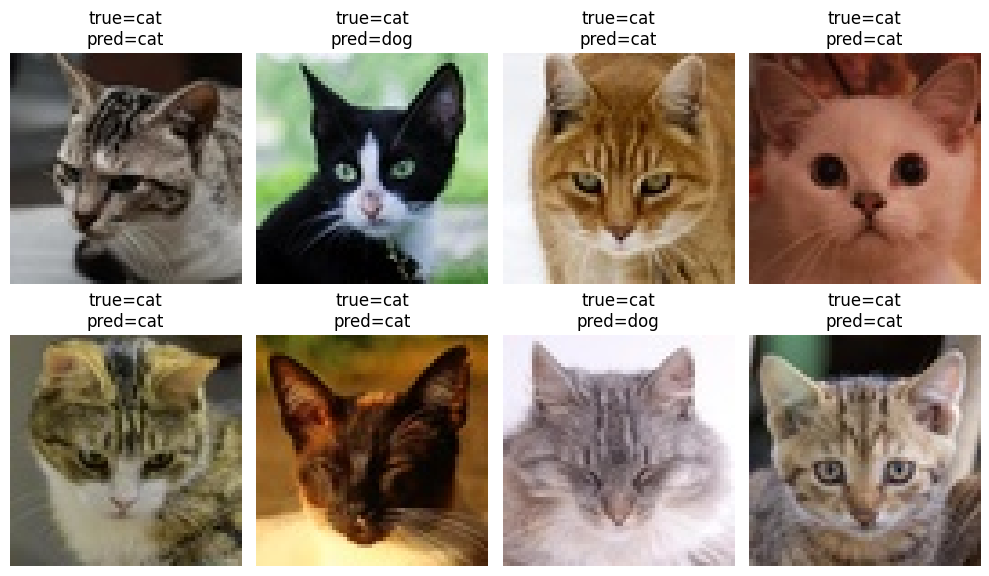

In [30]:
def accuracy_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float((y_true == y_pred).mean())

test_accuracy = accuracy_score(y_test, test_pred)
print(f"NumPy baseline accuracy: {test_accuracy:.3f}")

label_names = np.array(["cat", "dog"])
mistake_rows = []

for path, true_id, pred_id in zip(test_subset, y_test, test_pred):
    mistake_rows.append(
        {
            "filepath": str(path.relative_to(DATA_ROOT)),
            "label": label_names[true_id],
            "pred_numpy": label_names[pred_id],
            "correct_numpy": bool(true_id == pred_id),
        }
    )

output_path = NUMPY_PRED_PATH
with output_path.open("w", newline="") as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=["filepath", "label", "pred_numpy", "correct_numpy"],
    )
    writer.writeheader()
    writer.writerows(mistake_rows)

print(f"Saved predictions to: {output_path}")

plot_prediction_gallery(
    test_subset,
    label_names[y_test],
    label_names[test_pred],
    load_image,
    max_items=8,
    ncols=4,
    figsize=(10, 6),
)

wrong_examples = [row for row in mistake_rows if not row["correct_numpy"]][:5]
wrong_examples


## Reflection

Answer these short questions in your own words:

1. Why do we normalize pixel values before computing features?
2. Why might mean RGB fail on images with cluttered backgrounds?
3. Why does this baseline lose important spatial information?

**Optional extension**

Try one extra feature, such as:

- color channel ratios
- a sharper center crop
- a 16-bin grayscale histogram instead of 8 bins
